In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import re

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,mean_squared_error, r2_score, mean_absolute_error

import xgboost as xgb

from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.models import Sequential
from collections import Counter



In [2]:
data=pd.read_csv('/content/SolarPrediction.csv')
data.head()

,UNIXTime,Data,Time,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet
0,1475229326,9/29/2016 12:00:00 AM,23:55:26,1.21,48,30.46,59,177.39,5.62,06:13:00,18:13:00
1,1475229023,9/29/2016 12:00:00 AM,23:50:23,1.21,48,30.46,58,176.78,3.37,06:13:00,18:13:00
2,1475228726,9/29/2016 12:00:00 AM,23:45:26,1.23,48,30.46,57,158.75,3.37,06:13:00,18:13:00
3,1475228421,9/29/2016 12:00:00 AM,23:40:21,1.21,48,30.46,60,137.71,3.37,06:13:00,18:13:00
4,1475228124,9/29/2016 12:00:00 AM,23:35:24,1.17,48,30.46,62,104.95,5.62,06:13:00,18:13:00


In [3]:
df=data.copy()

In [4]:
df.shape

(32686, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32686 entries, 0 to 32685
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIXTime                32686 non-null  int64  
 1   Data                    32686 non-null  object 
 2   Time                    32686 non-null  object 
 3   Radiation               32686 non-null  float64
 4   Temperature             32686 non-null  int64  
 5   Pressure                32686 non-null  float64
 6   Humidity                32686 non-null  int64  
 7   WindDirection(Degrees)  32686 non-null  float64
 8   Speed                   32686 non-null  float64
 9   TimeSunRise             32686 non-null  object 
 10  TimeSunSet              32686 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 2.7+ MB


In [6]:
df.describe()

,UNIXTime,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
count,3.268600e+04,32686.000000,32686.000000,32686.000000,32686.000000,32686.000000,32686.000000
mean,1.478047e+09,207.124697,51.103255,30.422879,75.016307,143.489821,6.243869
std,3.005037e+06,315.916387,6.201157,0.054673,25.990219,83.167500,3.490474
min,1.472724e+09,1.110000,34.000000,30.190000,8.000000,0.090000,0.000000
25%,1.475546e+09,1.230000,46.000000,30.400000,56.000000,82.227500,3.370000
50%,1.478026e+09,2.660000,50.000000,30.430000,85.000000,147.700000,5.620000
75%,1.480480e+09,354.235000,55.000000,30.460000,97.000000,179.310000,7.870000
max,1.483265e+09,1601.260000,71.000000,30.560000,103.000000,359.950000,40.500000


In [7]:
df['Data'] = df['Data'].apply(lambda x: x.split()[0])

In [8]:
df['Month'] = pd.to_datetime(df['Data']).dt.month
df['Day'] = pd.to_datetime(df['Data']).dt.day
df['Hour'] = pd.to_datetime(df['Time']).dt.hour
df['Minute'] = pd.to_datetime(df['Time']).dt.minute
df['Second'] = pd.to_datetime(df['Time']).dt.second

/tmp/ipykernel_722/3244718825.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour
/tmp/ipykernel_722/3244718825.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Minute'] = pd.to_datetime(df['Time']).dt.minute
/tmp/ipykernel_722/3244718825.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Second'] = pd.to_datetime(df['Time']).dt.second


In [9]:
df['risehour'] = pd.to_datetime(df['TimeSunRise']).dt.hour
df['riseminute']=pd.to_datetime(df['TimeSunRise']).dt.minute

df['sethour'] = pd.to_datetime(df['TimeSunSet']).dt.hour
df['setminute'] = pd.to_datetime(df['TimeSunSet']).dt.minute

/tmp/ipykernel_722/978559654.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['risehour'] = pd.to_datetime(df['TimeSunRise']).dt.hour
/tmp/ipykernel_722/978559654.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['riseminute']=pd.to_datetime(df['TimeSunRise']).dt.minute
/tmp/ipykernel_722/978559654.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['sethour'] = pd.to_datetime(df['TimeSunSet']).dt.hour
/tmp/ipykernel_722/978559654.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsi

In [10]:

df.drop(['UNIXTime', 'Data', 'Time', 'TimeSunRise', 'TimeSunSet'], axis = 1, inplace = True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32686 entries, 0 to 32685
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Radiation               32686 non-null  float64
 1   Temperature             32686 non-null  int64  
 2   Pressure                32686 non-null  float64
 3   Humidity                32686 non-null  int64  
 4   WindDirection(Degrees)  32686 non-null  float64
 5   Speed                   32686 non-null  float64
 6   Month                   32686 non-null  int32  
 7   Day                     32686 non-null  int32  
 8   Hour                    32686 non-null  int32  
 9   Minute                  32686 non-null  int32  
 10  Second                  32686 non-null  int32  
 11  risehour                32686 non-null  int32  
 12  riseminute              32686 non-null  int32  
 13  sethour                 32686 non-null  int32  
 14  setminute               32686 non-null

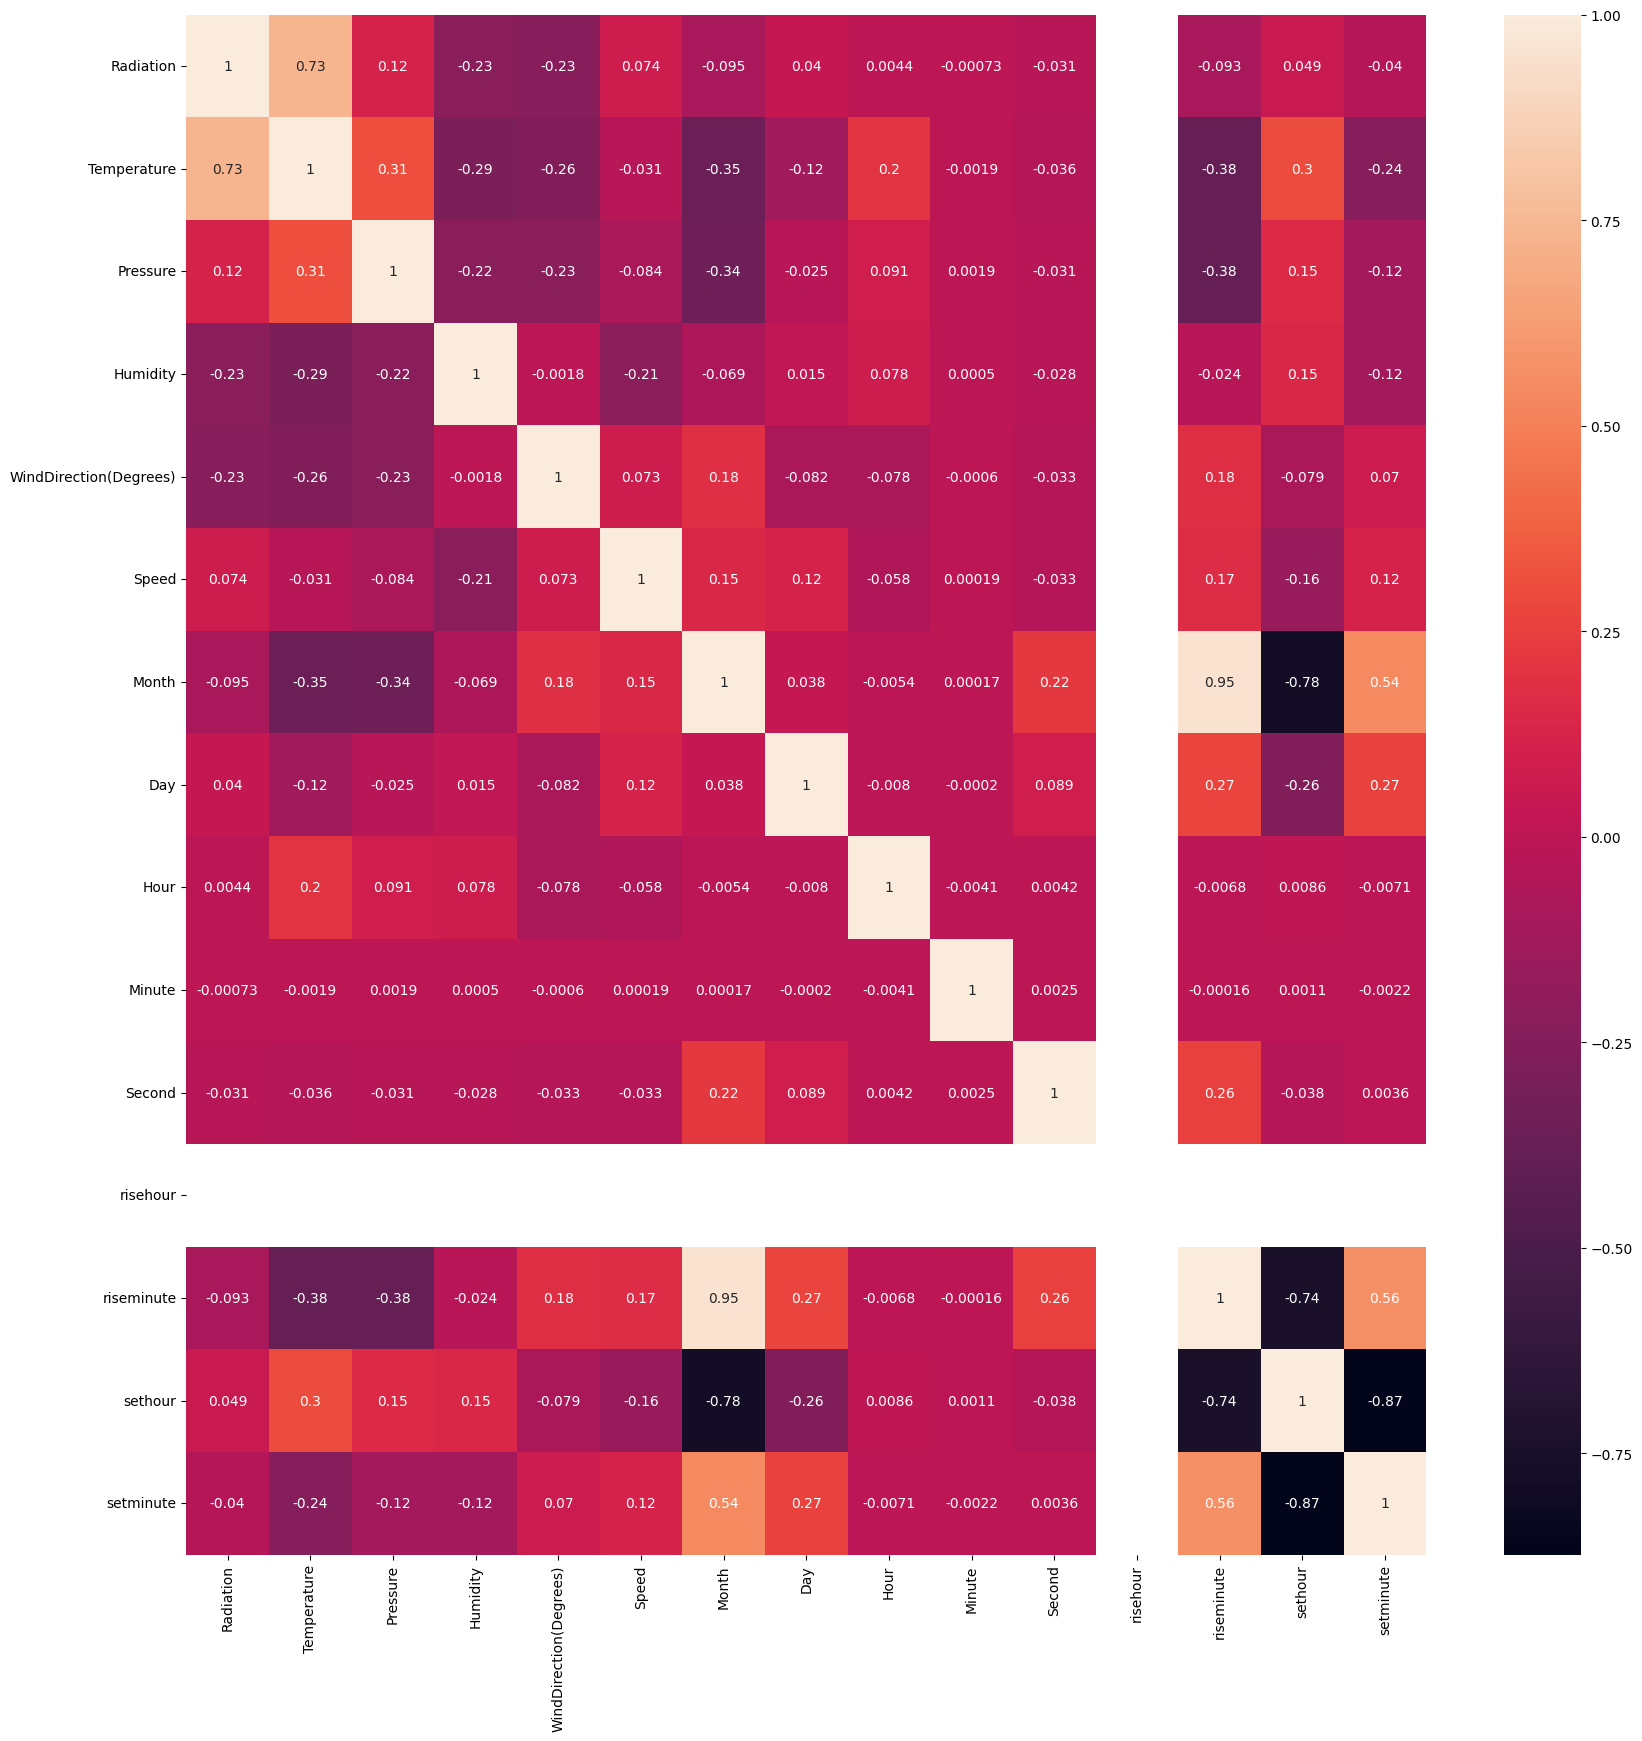

In [12]:
corr_matrix = df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [13]:
X = df.drop(['Radiation'], axis=1)
y = df['Radiation']

In [21]:
bestfeatures = SelectKBest(score_func = f_regression, k=5)

In [16]:
#y_train100 =  df['Radiation'].apply(lambda x : int(x*100))

In [22]:
scaled_X = MinMaxScaler().fit_transform(X)

In [23]:
fit = bestfeatures.fit(scaled_X, y)

In [24]:
scores = pd.DataFrame(fit.scores_)
column = pd.DataFrame(X.columns)

featureScores = pd.concat([column, scores], axis=1)
featureScores.columns = ['Features', 'feature_imp']

featureScores

,Features,feature_imp
0,Temperature,38392.663306
1,Pressure,469.611855
2,Humidity,1762.022981
3,WindDirection(Degrees),1830.983183
4,Speed,178.142906
5,Month,300.510636
6,Day,52.321046
7,Hour,0.632135
8,Minute,0.017406
9,Second,31.990633


In [25]:
featureScores.sort_values(by = 'feature_imp', ascending=False, inplace=True)
featureScores

,Features,feature_imp
0,Temperature,38392.663306
3,WindDirection(Degrees),1830.983183
2,Humidity,1762.022981
1,Pressure,469.611855
5,Month,300.510636
11,riseminute,284.222948
4,Speed,178.142906
12,sethour,77.761363
6,Day,52.321046
13,setminute,51.896708


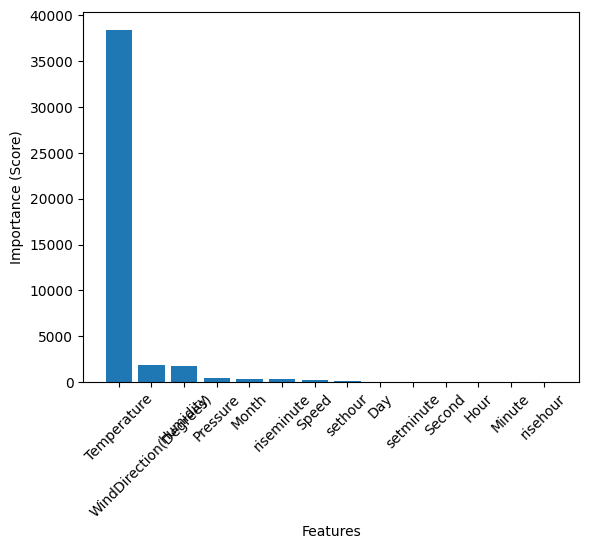

In [26]:
plt.bar(featureScores.Features, featureScores.feature_imp)
plt.xlabel("Features")
plt.ylabel("Importance (Score)")
plt.xticks(rotation=45)
plt.show()

In [27]:
from sklearn.ensemble import ExtraTreesRegressor
model_etc = ExtraTreesRegressor(n_estimators=5, verbose = 2) #n_estimators=to calculate no. of trees

In [28]:
model_etc.fit(scaled_X, y)

building tree 1 of 5
building tree 2 of 5
building tree 3 of 5
building tree 4 of 5
building tree 5 of 5


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    1.8s finished


ExtraTreesRegressor(n_estimators=5, verbose=2)

In [29]:
importances_etc = pd.DataFrame(model_etc.feature_importances_)
columns_etc = pd.DataFrame(X.columns)

df_etc = pd.concat([columns_etc, importances_etc], axis=1)
df_etc.columns = ['Features', 'feature_imp']

In [30]:
df_etc.sort_values(by = 'feature_imp', ascending=False, inplace=True)
df_etc

,Features,feature_imp
0,Temperature,0.502222
7,Hour,0.265995
2,Humidity,0.061300
3,WindDirection(Degrees),0.051006
6,Day,0.021976
1,Pressure,0.015783
12,sethour,0.015381
8,Minute,0.013381
11,riseminute,0.012527
13,setminute,0.012219


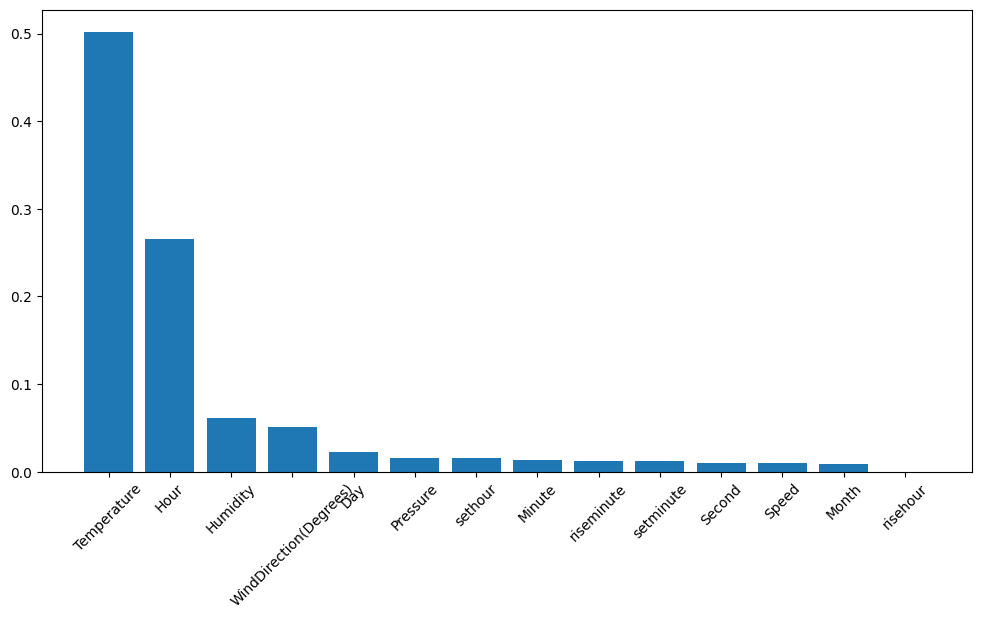

In [31]:
plt.figure(figsize=(12,6))
plt.bar(x=df_etc['Features'], height=df_etc['feature_imp'])
plt.xticks(rotation=45)
plt.show()

In [32]:
X = df.drop(['Radiation'], axis=1)
y = df['Radiation']

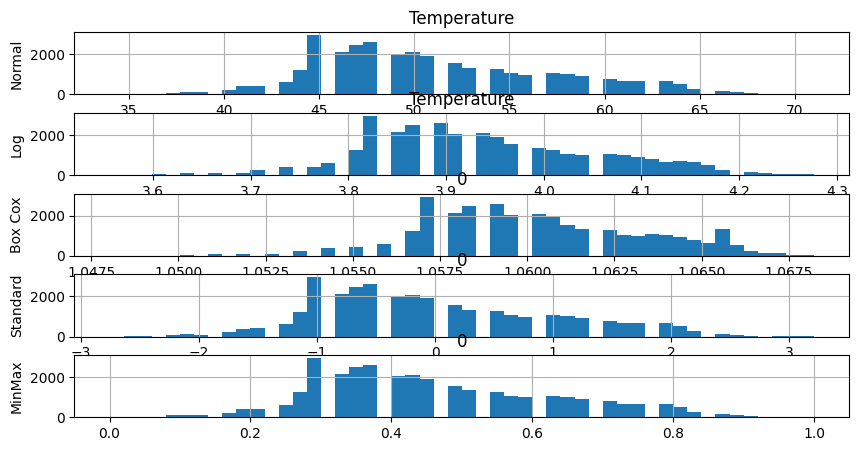

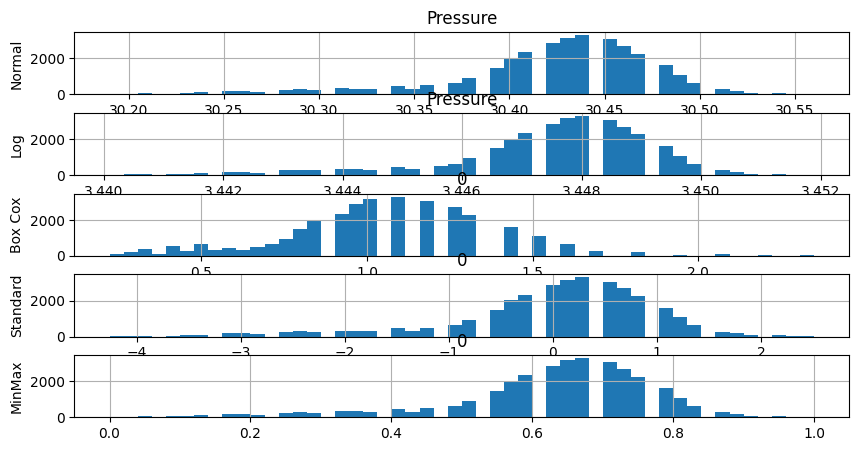

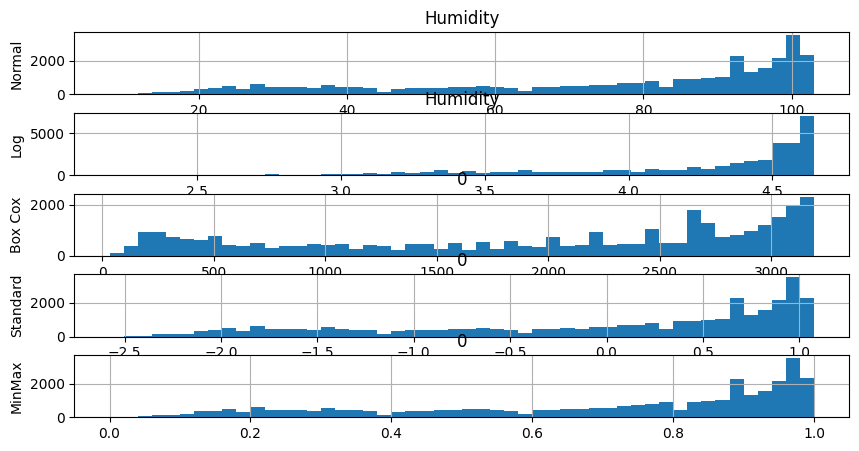

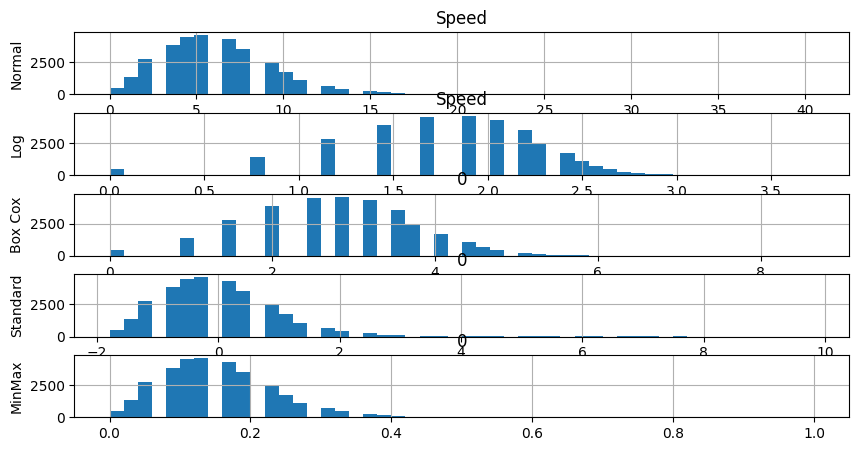

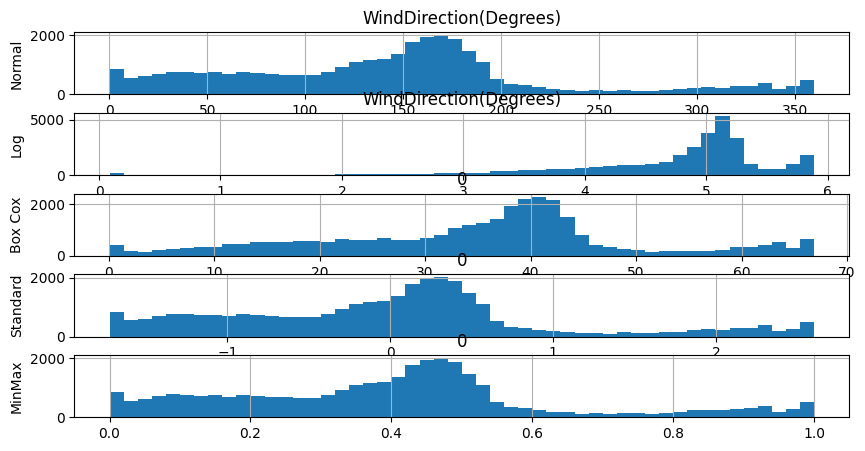

In [33]:
features_to_transform = ['Temperature', 'Pressure', 'Humidity', 'Speed', 'WindDirection(Degrees)']
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

for i in features_to_transform:
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 5))
    pd.DataFrame(X[i]).hist(ax = ax1, bins = 50)
    pd.DataFrame(np.log(X[i] + 1)).hist(ax=ax2, bins=50)
    pd.DataFrame(stats.boxcox(X[i]+1)[0]).hist(ax = ax3, bins = 50)
    scaled_data_standard = standard_scaler.fit_transform(X[[i]])
    pd.DataFrame(scaled_data_standard).hist(ax=ax4, bins=50)

    scaled_data_minmax = min_max_scaler.fit_transform(X[[i]])
    pd.DataFrame(scaled_data_minmax).hist(ax=ax5, bins=50)

    ax1.set_ylabel('Normal')
    ax2.set_ylabel('Log')
    ax3.set_ylabel('Box Cox')
    ax4.set_ylabel('Standard')
    ax5.set_ylabel('MinMax')


In [34]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [35]:
X_train.shape, X_test.shape

((26148, 14), (6538, 14))

In [36]:
from xgboost import XGBRegressor


model_xgb = XGBRegressor(learning_rate=0.1,
    max_depth=8,
    n_estimators=100,
    random_state=42)

In [37]:
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [38]:
y_prediction = model_xgb.predict(X_test)

In [41]:


r2 = r2_score(y_test, y_prediction)
print("Testing performance")
print("R2: {:.2f}".format(r2))

Testing performance
R2: 0.93


In [42]:
import keras
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.models import Sequential

In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler =StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
model = None
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=X_train.shape[1])) #input_dim = n_columns
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(1, activation='linear'))

# compiling all
model.compile(metrics= ['mae'], loss='mse', optimizer= Adam(learning_rate=0.005))
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [65]:

history = model.fit(X_train, y_train, validation_split=0.1, epochs=50, batch_size=32)

Epoch 1/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 30196.1992 - mae: 97.9488 - val_loss: 17102.1973 - val_mae: 72.0625
Epoch 2/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 17042.8281 - mae: 68.5490 - val_loss: 13346.0088 - val_mae: 58.4745
Epoch 3/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 15483.8760 - mae: 64.1135 - val_loss: 12578.9707 - val_mae: 55.8383
Epoch 4/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14190.5703 - mae: 60.6192 - val_loss: 11771.7480 - val_mae: 54.3149
Epoch 5/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 13604.7549 - mae: 58.8230 - val_loss: 11452.2383 - val_mae: 53.2906
Epoch 6/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 13019.0195 - mae: 57.4718 - val_loss: 9655.1514 - val_mae: 48.1890
Epoch 7/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12819.6924 - mae: 57.3719 - val_loss: 9673.1455 - val_mae: 47.2395
Epoch 8/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12674.0586 - mae: 56.9166 - val_loss: 11417.22

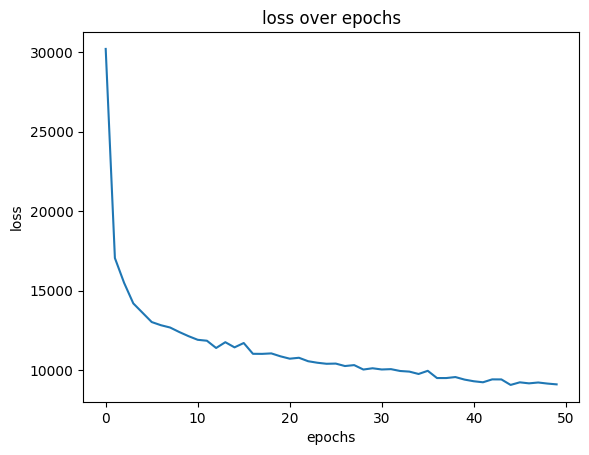

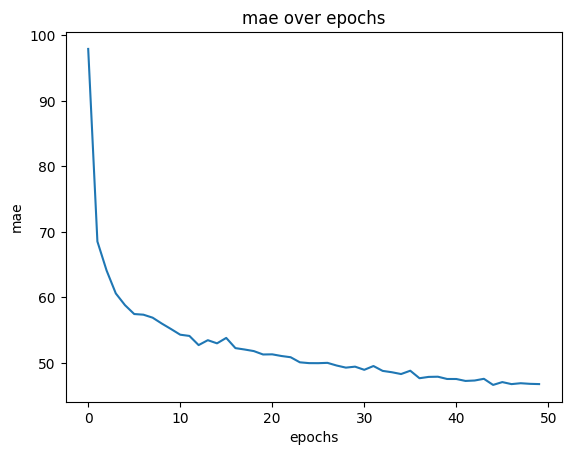

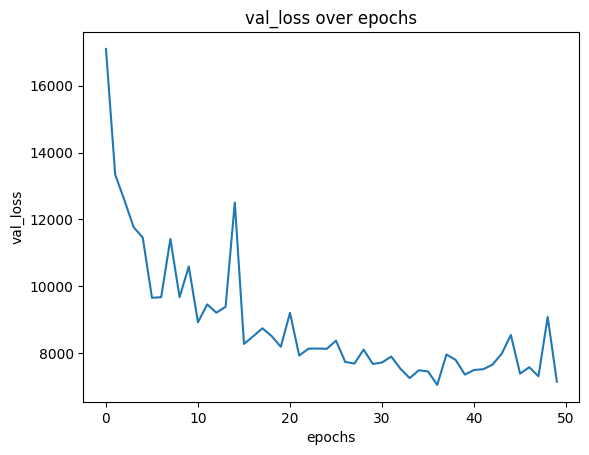

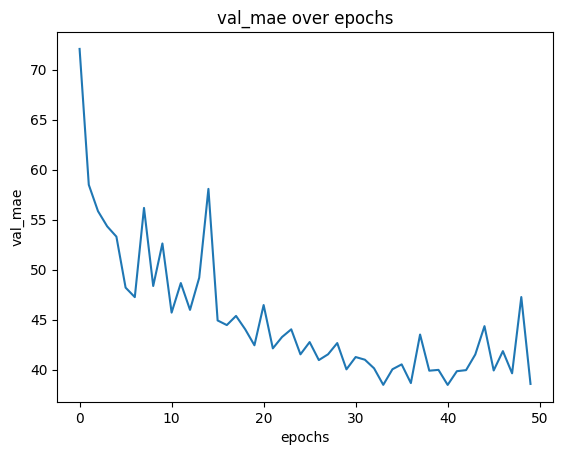

In [66]:
fit = history.history
for i in fit:
    plt.plot(fit[i])
    plt.title(i + ' over epochs')
    plt.ylabel(i)
    plt.xlabel('epochs')
    plt.show()

In [67]:
y_prediction_mlp =model.predict(X_test)

205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [68]:

r2_mlp = r2_score(y_test, y_prediction_mlp)
print("Testing performance")
print("R2: {:.2f}".format(r2_mlp))


Testing performance
R2: 0.92
